# 4.1 諸々試作（実装版）

4.0-穴あきノートブックの穴をすべて埋めた実装版。  
まず動かして結果を確認し、パラメータや手法を差し替えて試行する。

**データ**: `cleaned_three_species_train.csv`（1167×1559, 13樹種）  
**評価指標**: RMSE（小さいほど良い）  
**CV戦略**: GroupKFold by 樹種

## 1. 環境セットアップ

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib

from scipy.signal import savgol_filter
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.model_selection import GroupKFold
from sklearn.metrics import root_mean_squared_error

import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('..')
from project.config import RAW_DATA_DIR, INTERIM_DATA_DIR, PROCESSED_DATA_DIR

print('import OK')

import OK


## 2. データ読み込み

In [2]:
train = pd.read_csv(INTERIM_DATA_DIR / 'cleaned_three_species_train.csv', encoding='shift-jis')
test  = pd.read_csv(RAW_DATA_DIR / 'test.csv', encoding='shift-jis')

META_COLS  = ['sample number', 'species number', '樹種']
TARGET_COL = '含水率'
SPEC_COLS  = [c for c in train.columns if c not in META_COLS + [TARGET_COL]]

wavenumbers  = np.array(SPEC_COLS, dtype=float)
X_train_raw  = train[SPEC_COLS].values
y_train      = train[TARGET_COL].values
groups       = train['樹種'].values
X_test_raw   = test[SPEC_COLS].values

print(f'train: {train.shape}, test: {test.shape}')
print(f'スペクトル列数: {len(SPEC_COLS)}')
print(f'train 樹種: {list(train["樹種"].unique())}')
print(f'test  樹種: {list(test["樹種"].unique())}')
print(f'含水率 range: {y_train.min():.2f} ~ {y_train.max():.2f} %')

train: (1167, 1559), test: (550, 1558)
スペクトル列数: 1555
train 樹種: ['イチョウ', 'ウエンジ', 'ウォールナット', 'クリ', 'スプルース', 'チェリー', 'トチ', 'ナラ', 'ヒノキ', 'ベイスギ', '米ヒバ', 'ベイマツ', 'ホワイトオーク']
test  樹種: ['クスノキ', 'ケヤキ', 'スギ', 'タモ', 'チーク', 'ヤマザクラ']
含水率 range: 0.84 ~ 298.58 %


## 3. 前処理

In [3]:
def snv(X: np.ndarray) -> np.ndarray:
    """Standard Normal Variate: 行単位で (X - mean) / std"""
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1, keepdims=True)
    return (X - mean) / std


def sg_deriv(X: np.ndarray, window: int = 11, poly: int = 2, deriv: int = 2) -> np.ndarray:
    """Savitzky-Golay 微分"""
    return savgol_filter(X, window_length=window, polyorder=poly, deriv=deriv, axis=1)


def msc(X: np.ndarray, ref: np.ndarray = None):
    """Multiplicative Scatter Correction。ref=None なら X の平均を基準に使う"""
    if ref is None:
        ref = X.mean(axis=0)
    X_out = np.zeros_like(X)
    for i in range(len(X)):
        a, b = np.polyfit(ref, X[i], 1)
        X_out[i] = (X[i] - b) / a
    return X_out, ref


# ----- 各前処理の適用 -----
X_train_snv = snv(X_train_raw)
X_test_snv  = snv(X_test_raw)

X_train_sg  = sg_deriv(X_train_snv)
X_test_sg   = sg_deriv(X_test_snv)

X_train_msc, ref_spectrum = msc(X_train_raw)
X_test_msc,  _            = msc(X_test_raw, ref=ref_spectrum)

print('前処理 完了')
print(f'  SNV shape:      {X_train_snv.shape}')
print(f'  SNV+SG2d shape: {X_train_sg.shape}')
print(f'  MSC shape:      {X_train_msc.shape}')

前処理 完了
  SNV shape:      (1167, 1555)
  SNV+SG2d shape: (1167, 1555)
  MSC shape:      (1167, 1555)


## 4. 特徴量エンジニアリング

### 4-A: 水の吸収ピーク帯域特徴量

In [4]:
def extract_peak_features(X: np.ndarray, wn: np.ndarray) -> pd.DataFrame:
    """
    水の吸収ピーク帯域（~8500 / ~6900 / ~5200 cm⁻¹）の統計量を特徴量として抽出
    """
    peak_bands = {
        'OH2nd': (8300, 8700),   # OHの第2倍音
        'OH1st': (6700, 7100),   # OHの第1倍音
        'comb':  (5000, 5400),   # 結合音
    }
    features = {}
    for name, (lo, hi) in peak_bands.items():
        mask = (wn >= lo) & (wn <= hi)
        band = X[:, mask]
        band_wn = wn[mask]
        features[f'{name}_mean'] = band.mean(axis=1)
        features[f'{name}_max']  = band.max(axis=1)
        features[f'{name}_std']  = band.std(axis=1)
        features[f'{name}_area'] = np.trapz(band, band_wn, axis=1)

    # 帯域間の比（物理的に意味のある特徴量）
    features['OH2nd_OH1st_ratio'] = features['OH2nd_mean'] / (features['OH1st_mean'] + 1e-10)
    features['OH1st_comb_ratio']  = features['OH1st_mean'] / (features['comb_mean']  + 1e-10)

    return pd.DataFrame(features)


feat_peak_train = extract_peak_features(X_train_snv, wavenumbers)
feat_peak_test  = extract_peak_features(X_test_snv,  wavenumbers)

print('ピーク特徴量:', feat_peak_train.shape)
feat_peak_train.head(3)

ピーク特徴量: (1167, 14)


,OH2nd_mean,OH2nd_max,OH2nd_std,OH2nd_area,OH1st_mean,OH1st_max,OH1st_std,OH1st_area,comb_mean,comb_max,comb_std,comb_area,OH2nd_OH1st_ratio,OH1st_comb_ratio
0,-0.878631,-0.849856,0.027212,348.971821,1.065320,1.157706,0.092731,-419.871854,1.519505,1.881358,0.492151,-605.576179,-0.824758,0.701097
1,-0.874786,-0.843198,0.029447,347.443767,1.058082,1.159869,0.101681,-417.055211,1.565767,2.000933,0.544513,-624.122580,-0.826766,0.675759
2,-0.872927,-0.839793,0.030528,346.701228,1.034984,1.135666,0.100557,-407.951746,1.568581,2.019350,0.551197,-625.247115,-0.843420,0.659822


### 4-B: PCA次元削減

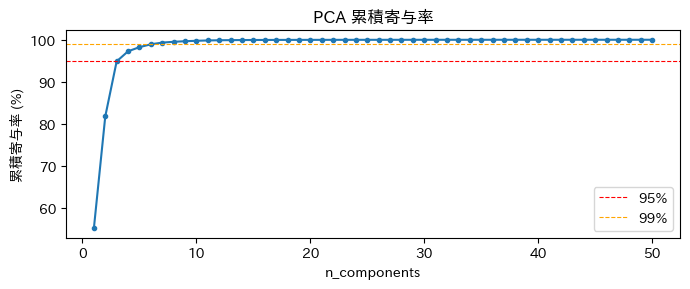

95%到達: 4 成分, 99%到達: 7 成分
PCA特徴量: (1167, 50)


In [5]:
def fit_pca(X_train: np.ndarray, n_components: int = 50, plot_variance: bool = True):
    """
    StandardScaler → PCA でtrain fitし、変換済み配列・scaler・pca を返す
    """
    scaler = StandardScaler()
    X_sc   = scaler.fit_transform(X_train)

    pca   = PCA(n_components=n_components, random_state=42)
    X_pca = pca.fit_transform(X_sc)

    if plot_variance:
        cum_var = np.cumsum(pca.explained_variance_ratio_) * 100
        plt.figure(figsize=(7, 3))
        plt.plot(range(1, n_components + 1), cum_var, marker='o', ms=3)
        plt.axhline(95, color='red', ls='--', lw=0.8, label='95%')
        plt.axhline(99, color='orange', ls='--', lw=0.8, label='99%')
        plt.xlabel('n_components')
        plt.ylabel('累積寄与率 (%)')
        plt.title('PCA 累積寄与率')
        plt.legend()
        plt.tight_layout()
        plt.show()
        print(f'95%到達: {np.argmax(cum_var >= 95) + 1} 成分, 99%到達: {np.argmax(cum_var >= 99) + 1} 成分')

    return scaler, pca, X_pca


# SNVスペクトルでPCA（n=50で寄与率確認後に調整）
scaler_pca, pca_model, X_train_pca = fit_pca(X_train_snv, n_components=50)
X_test_pca = pca_model.transform(scaler_pca.transform(X_test_snv))

print(f'PCA特徴量: {X_train_pca.shape}')

### 4-C: 特徴量の結合

ここで使う特徴量を選んで `X_train_feat` / `X_test_feat` に代入する。

In [6]:
# ---- 使う特徴量を選択 ----

# パターン A: SNV 生スペクトル（PLSR向け）
X_for_plsr_train = X_train_sg
X_for_plsr_test  = X_test_sg

# パターン B: PCA + ピーク特徴量（LightGBM向け）
X_for_lgbm_train = np.hstack([X_train_pca, feat_peak_train.values])
X_for_lgbm_test  = np.hstack([X_test_pca,  feat_peak_test.values])

print(f'PLSR用 特徴量: {X_for_plsr_train.shape}')
print(f'LGBM用 特徴量: {X_for_lgbm_train.shape}')

PLSR用 特徴量: (1167, 1555)
LGBM用 特徴量: (1167, 64)


## 5. CV設定

In [7]:
N_SPLITS = 5
gkf = GroupKFold(n_splits=N_SPLITS)

print(f'GroupKFold (n_splits={N_SPLITS}, グループ=樹種)')
for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_for_plsr_train, y_train, groups=groups)):
    print(f'  Fold {fold}: val={sorted(set(groups[va_idx]))}')

GroupKFold (n_splits=5, グループ=樹種)
  Fold 0: val=['トチ', 'ヒノキ']
  Fold 1: val=['ウォールナット', 'チェリー']
  Fold 2: val=['ウエンジ', 'ナラ', 'ホワイトオーク']
  Fold 3: val=['クリ', 'スプルース', 'ベイスギ']
  Fold 4: val=['イチョウ', 'ベイマツ', '米ヒバ']


## 6. モデル学習

### 6-A: PLSR

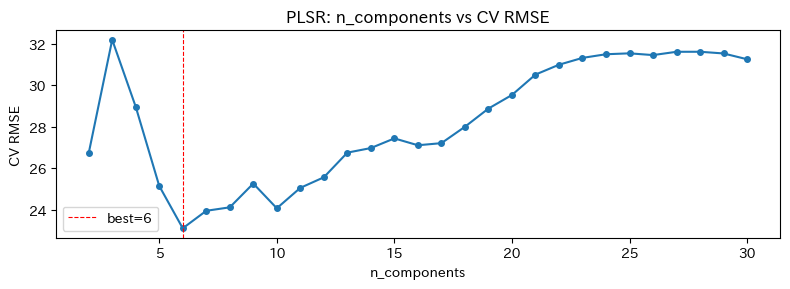

PLSR  最適 n_components=6  CV RMSE=24.4313


In [8]:
def train_plsr_cv(X: np.ndarray, y: np.ndarray, groups: np.ndarray,
                  X_test: np.ndarray,
                  n_components_range=range(2, 31)) -> dict:
    """
    Step1: n_components を CV でグリッドサーチ
    Step2: 最適値で GroupKFold CV → OOF予測 + test予測（fold平均）
    """
    # --- Step1: n_components 探索 ---
    nc_rmses = {}
    for nc in n_components_range:
        fold_rmses = []
        for tr_idx, va_idx in gkf.split(X, y, groups=groups):
            model = PLSRegression(n_components=nc)
            model.fit(X[tr_idx], y[tr_idx])
            pred  = model.predict(X[va_idx]).ravel()
            fold_rmses.append(root_mean_squared_error(y[va_idx], pred))
        nc_rmses[nc] = np.mean(fold_rmses)

    best_n    = min(nc_rmses, key=nc_rmses.get)
    best_rmse = nc_rmses[best_n]

    # 探索結果の可視化
    plt.figure(figsize=(8, 3))
    plt.plot(list(nc_rmses.keys()), list(nc_rmses.values()), marker='o', ms=4)
    plt.axvline(best_n, color='red', ls='--', lw=0.8, label=f'best={best_n}')
    plt.xlabel('n_components')
    plt.ylabel('CV RMSE')
    plt.title('PLSR: n_components vs CV RMSE')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Step2: 最適 n_components で OOF / test 予測 ---
    oof_preds  = np.zeros(len(y))
    test_preds = np.zeros(len(X_test))

    for tr_idx, va_idx in gkf.split(X, y, groups=groups):
        model = PLSRegression(n_components=best_n)
        model.fit(X[tr_idx], y[tr_idx])
        oof_preds[va_idx]  = model.predict(X[va_idx]).ravel()
        test_preds        += model.predict(X_test).ravel() / N_SPLITS

    cv_rmse = root_mean_squared_error(y, oof_preds)
    print(f'PLSR  最適 n_components={best_n}  CV RMSE={cv_rmse:.4f}')
    return {
        'model_name':  'PLSR',
        'oof_preds':   oof_preds,
        'test_preds':  test_preds,
        'cv_rmse':     cv_rmse,
        'best_params': {'n_components': best_n},
    }


result_plsr = train_plsr_cv(X_for_plsr_train, y_train, groups, X_test=X_for_plsr_test)

### 6-B: LightGBM

In [9]:
def train_lgbm_cv(X: np.ndarray, y: np.ndarray, groups: np.ndarray,
                  X_test: np.ndarray,
                  params: dict = None) -> dict:
    """
    LightGBM を GroupKFold CV で学習。Early stopping 付き。
    test予測は各 fold の予測を平均する。
    """
    if params is None:
        params = {
            'objective':        'regression',
            'metric':           'rmse',
            'learning_rate':    0.05,
            'num_leaves':       31,
            'feature_fraction': 0.8,
            'bagging_fraction': 0.8,
            'bagging_freq':     5,
            'min_child_samples': 20,
            'random_state':     42,
            'verbose':          -1,
        }

    oof_preds  = np.zeros(len(y))
    test_preds = np.zeros(len(X_test))

    for fold, (tr_idx, va_idx) in enumerate(gkf.split(X, y, groups=groups)):
        dtrain = lgb.Dataset(X[tr_idx], label=y[tr_idx])
        dval   = lgb.Dataset(X[va_idx], label=y[va_idx], reference=dtrain)

        callbacks = [
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=-1),
        ]
        model = lgb.train(
            params,
            dtrain,
            num_boost_round=1000,
            valid_sets=[dval],
            callbacks=callbacks,
        )
        oof_preds[va_idx]  = model.predict(X[va_idx])
        test_preds        += model.predict(X_test) / N_SPLITS

        fold_rmse = root_mean_squared_error(y[va_idx], oof_preds[va_idx])
        print(f'  Fold {fold}: RMSE={fold_rmse:.4f}, best_iter={model.best_iteration}')

    cv_rmse = root_mean_squared_error(y, oof_preds)
    print(f'LightGBM  CV RMSE={cv_rmse:.4f}')
    return {
        'model_name': 'LightGBM',
        'oof_preds':  oof_preds,
        'test_preds': test_preds,
        'cv_rmse':    cv_rmse,
    }


result_lgbm = train_lgbm_cv(X_for_lgbm_train, y_train, groups, X_test=X_for_lgbm_test)

  Fold 0: RMSE=15.0604, best_iter=88
  Fold 1: RMSE=21.2795, best_iter=27
  Fold 2: RMSE=20.8939, best_iter=30
  Fold 3: RMSE=50.8935, best_iter=160
  Fold 4: RMSE=14.3446, best_iter=75
LightGBM  CV RMSE=28.3945


## 7. アンサンブル

In [10]:
def ensemble_predictions(results: list, mode: str = 'equal') -> np.ndarray:
    """
    mode='equal'  : 等重み平均
    mode='rmse'   : 1/RMSE を正規化した加重平均（CVが良いモデルを重視）
    """
    preds = np.stack([r['test_preds'] for r in results], axis=0)  # (n_models, n_test)

    if mode == 'equal':
        weights = np.ones(len(results)) / len(results)
    elif mode == 'rmse':
        inv_rmse = np.array([1.0 / r['cv_rmse'] for r in results])
        weights  = inv_rmse / inv_rmse.sum()
    else:
        raise ValueError(f'unknown mode: {mode}')

    print('アンサンブル重み:')
    for r, w in zip(results, weights):
        print(f'  {r["model_name"]}: weight={w:.3f}  (CV RMSE={r["cv_rmse"]:.4f})')

    return (preds * weights[:, None]).sum(axis=0)


results = [result_plsr, result_lgbm]

test_pred_equal = ensemble_predictions(results, mode='equal')
print()
test_pred_rmse  = ensemble_predictions(results, mode='rmse')

アンサンブル重み:
  PLSR: weight=0.500  (CV RMSE=24.4313)
  LightGBM: weight=0.500  (CV RMSE=28.3945)

アンサンブル重み:
  PLSR: weight=0.538  (CV RMSE=24.4313)
  LightGBM: weight=0.462  (CV RMSE=28.3945)


### OOF予測の可視化（実測 vs 予測）

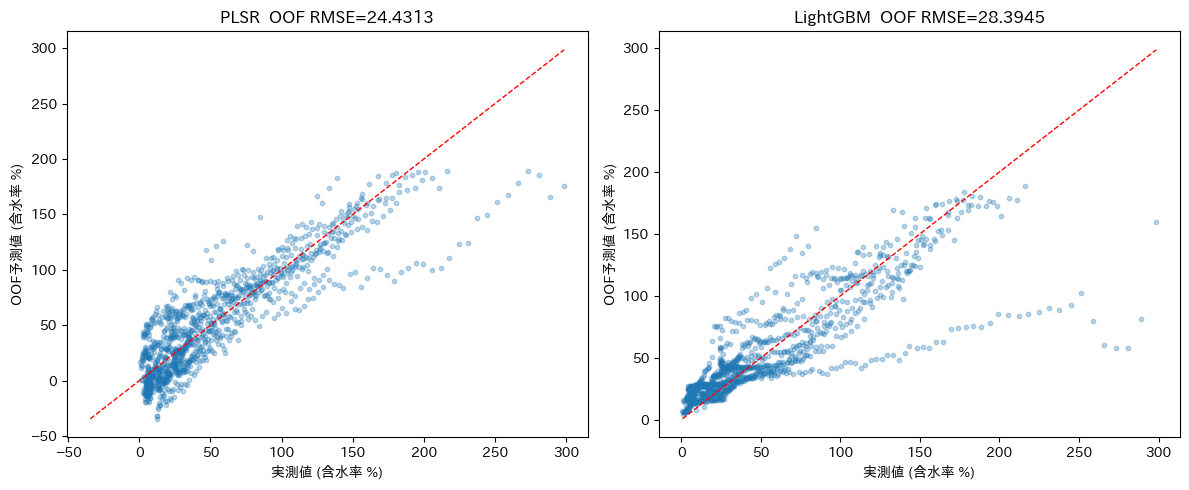

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, result in zip(axes, results):
    oof = result['oof_preds']
    ax.scatter(y_train, oof, alpha=0.3, s=10)
    lim = [min(y_train.min(), oof.min()), max(y_train.max(), oof.max())]
    ax.plot(lim, lim, 'r--', lw=1)
    ax.set_xlabel('実測値 (含水率 %)')
    ax.set_ylabel('OOF予測値 (含水率 %)')
    ax.set_title(f'{result["model_name"]}  OOF RMSE={result["cv_rmse"]:.4f}')

plt.tight_layout()
plt.show()

## 8. Submission生成

In [12]:
def save_submission(test_preds: np.ndarray, version: str) -> None:
    sample = pd.read_csv(RAW_DATA_DIR / 'sample_submit.csv',
                         encoding='shift-jis', header=None)
    sub = sample.copy()
    sub.iloc[:, 1] = test_preds
    path = PROCESSED_DATA_DIR / f'submission_{version}.csv'
    sub.to_csv(path, index=False, header=False, encoding='shift-jis')
    print(f'Saved → {path}')
    print(sub.iloc[:, 1].describe().to_string())


# PLSR単体
save_submission(result_plsr['test_preds'],  version='v4_1_plsr')
print()
# LightGBM単体
save_submission(result_lgbm['test_preds'],  version='v4_1_lgbm')
print()
# アンサンブル（RMSE加重）
save_submission(test_pred_rmse,             version='v4_1_ensemble_rmse')

Saved → /Users/kudoshunya/Documents/実験/project/data/processed/submission_v4_1_plsr.csv
count    550.000000
mean      50.901577
std       44.645200
min      -16.344960
25%       22.052837
50%       29.650493
75%       80.023216
max      171.854302

Saved → /Users/kudoshunya/Documents/実験/project/data/processed/submission_v4_1_lgbm.csv
count    550.000000
mean      51.197977
std       35.861822
min       18.213130
25%       23.491486
50%       33.576479
75%       72.372292
max      165.811384

Saved → /Users/kudoshunya/Documents/実験/project/data/processed/submission_v4_1_ensemble_rmse.csv
count    550.000000
mean      51.038659
std       39.973803
min        1.883270
25%       23.000802
50%       30.715378
75%       76.589642
max      169.059526


## 9. 結果まとめ

| version | 前処理 | 特徴量 | モデル | CV RMSE | LB スコア | 備考 |
|---|---|---|---|---|---|---|
| v4_1_plsr | SNV+SG2次微分 | 生スペクトル（1555次元） | PLSR (n=6) | **24.43** | - | |
| v4_1_lgbm | SNV+PCA(50)+ピーク | PCA50+ピーク14次元=64次元 | LightGBM | **28.39** | - | Fold3が突出して悪い (ベイスギ等) |
| v4_1_ensemble_rmse | - | - | PLSR×0.54+LGBM×0.46 | - | - | RMSE加重アンサンブル |
